<a href="https://colab.research.google.com/github/bigdatahub-ap/indonesia-workshop-on-use-of-ads/blob/main/notebooks/Index_Calculation_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparation
In order to calculate indices in R we need to install some packages that are not pre-installed in google colab.

In [ ]:
# Install required packages
install.packages(c('PriceIndices', 'IndexNumR'), repos='https://cran.r-project.org')

# Set the options such that unnessecary warnings are muted
knitr::opts_chunk$set(echo = TRUE)
options(tidyverse.quiet = TRUE)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘stringdist’, ‘lpSolve’, ‘checkmate’, ‘reshape’, ‘reclin2’, ‘strex’, ‘lazyeval’, ‘crosstalk’




This notebook presents two packages that are able to calculate multilateral indices. The packages are `PriceIndices` and  `IndexNumR`. In addition we use popular packages for data manipulation and visualisation.


In [ ]:
library(PriceIndices) # for price index calculations
library(IndexNumR)    # for price index calculations
library(tidyverse)    # for data analysis
library(ggplot2)      # for graphics


Attaching package: ‘IndexNumR’


The following object is masked from ‘package:PriceIndices’:

    elasticity




## Dataset

We use data from a set of food prices in Italian supermarkets provided by Banca d'Italia, Università Campus Bio-Medico and Università degli Studi della Tuscia. The complete dataset is available [here](https://zenodo.org/records/14927602). We aggregated the data by month and added artificial quantities.

> **Note:** Each row represents one product in one month, with its price and quantity sold.


In [ ]:
url_avg_price_data <- 'https://raw.githubusercontent.com/UN-Task-Team-for-Scanner-Data/alternative-data-sources-price-statistics/refs/heads/main/data/monthly_avg_price_with_qty.csv'
data <- read_csv(url_avg_price_data, show_col_types = FALSE)
head(data)

month_year,product,store_id,COICOP5,COICOP4,price,quantity,total_quantity,quantity_share
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2020-12,abate arg biologico 600.0 gr,6,Pears,Fruit,2.98,443.9526,998075.4,0.0004448087
2021-01,abate arg biologico 600.0 gr,6,Pears,Fruit,2.98,462.0903,1075015.9,0.0004298450
2021-02,abate arg biologico 600.0 gr,6,Pears,Fruit,2.98,451.6173,1088432.1,0.0004149246
2021-03,abate arg biologico 600.0 gr,6,Pears,Fruit,2.98,439.1331,1124145.1,0.0003906374
2021-04,abate arg biologico 600.0 gr,6,Pears,Fruit,3.78,378.1872,1084118.1,0.0003488432
2021-05,abate arg biologico 600.0 gr,6,Pears,Fruit,3.78,394.0985,1080937.4,0.0003645895


As we have seen in previous sessions, we need to prepare the data before we can start making calculations.


In [ ]:
# Filter for apples in Store 3
data <- data %>% filter(COICOP5 %in% "Apples" & store_id %in% 3) %>%
         mutate(product_id = as.numeric(factor(product)),
                volume = price * quantity,
                total_quantity = NULL, quantity_share = NULL)

# Extract package size from product description and convert to kg
data <- data %>% mutate(size = case_when(
  str_sub(product, -2, -1) == "kg" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")),
  str_sub(product, -2, -1) == "gr" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")) / 1000,
  str_sub(product, -2, -1) == "pz" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")) * .18))

# Adjust price to "per kg" and quantity to "kg sold"
data <- data %>% mutate(price = price / size, quantity = quantity * size)


# Index calculation



#### The `PriceIndices` package

`PriceIndices` is an R-Package for price index calculation written by Jacek Bialek. A [user guide](https://github.com/JacekBialek/important_documents/blob/main/README.pdf) and a more detailed [manual](https://github.com/JacekBialek/important_documents/blob/main/PriceIndices_manual.pdf) are available.    
The core of the package are functions to calculate both bilateral and multilateral indices. It has an extensive variety of price index formulas and methods. Furthermore it includes a data set from polish supermarkets. There are some functions for data processing (e.g. price imputation for missing prices, data aggregation, filtering, stratification) as well as some functions to compare results and visualise data.

The package only calculates monthly indices and the datasets must meet some conditions. It must contain the following correctly named columns:

| Column | Type | Description |
|---|---|---|
| `time` | Date `yyyy-mm-dd` | Observation period |
| `prodID` | numeric / character | Product identifier |
| `prices` | numeric > 0 | Price |
| `quantities` | numeric > 0 | Quantity sold |


The formatting can be done using typical data processing functions or by using the function `PriceIndices::data_preparing`.



This dataframe has the input that PriceIndices needs:



time,prices,quantities,prodID,retID,description,grammage
<date>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>
2020-12-01,2.480000,69.35014,1,3,annurca igp 1.0 kg,1
2021-01-01,2.480000,68.78552,1,3,annurca igp 1.0 kg,1
2021-02-01,2.480000,66.91396,1,3,annurca igp 1.0 kg,1
2021-03-01,2.542069,74.88717,1,3,annurca igp 1.0 kg,1
2021-04-01,2.580000,70.78103,1,3,annurca igp 1.0 kg,1
2021-05-01,2.580000,98.40473,1,3,annurca igp 1.0 kg,1




This is the output:



time,jevons,chjevons,laspeyres,chlaspeyres,tornqvist,chtornqvist
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2020-12,1.000000,1.000000,1.0000000,1.0000000,1.0000000,1.0000000
2021-01,1.003516,1.003516,0.9962611,0.9962611,0.9927261,0.9927261
2021-02,1.008031,1.032144,1.0092834,1.0248807,1.0100238,1.0213515
2021-03,1.017095,1.030811,1.0196261,1.0360540,1.0191613,1.0316011
2021-04,1.064037,1.078588,1.0441499,1.0678127,1.0436520,1.0622712
2021-05,1.082721,1.091466,1.0555536,1.0756050,1.0550994,1.0698487
2021-06,1.067447,1.084472,1.0473502,1.0713029,1.0454470,1.0652976
2021-07,1.057320,1.089739,1.0607033,1.0747769,1.0610128,1.0685044
2021-08,1.057320,1.089739,1.0607033,1.0747769,1.0627700,1.0685044




Visualisations help to compare the results:

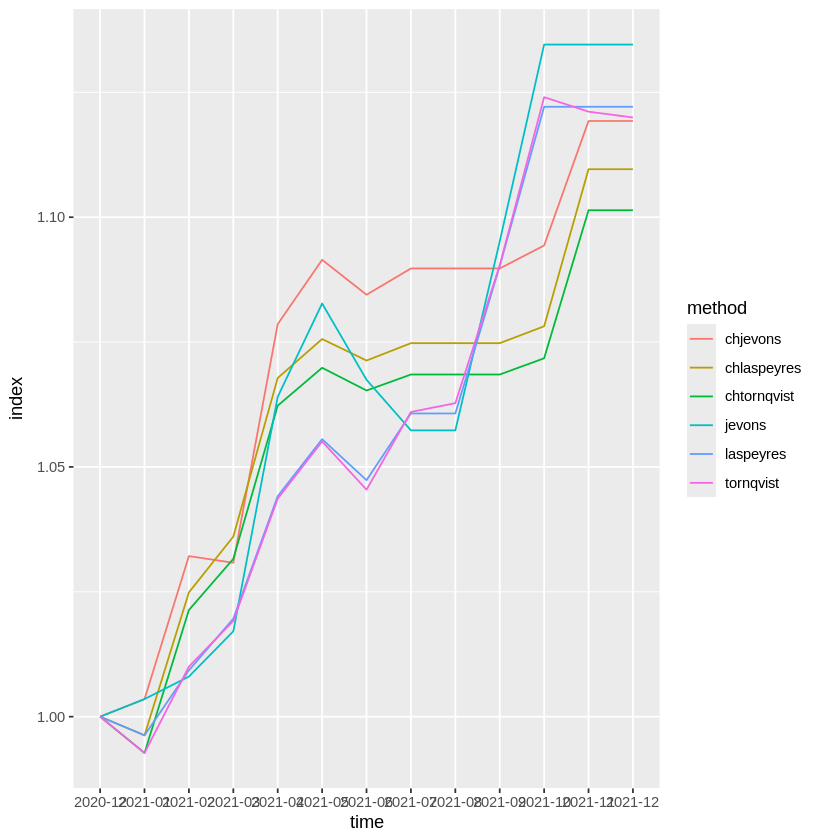

In [ ]:
# We start by adding the correctly named columns and change the format of time as date
cat("This dataframe has the input that PriceIndices needs:\n\n")
data_preparing(data,
               time = "month_year", # convert the period into date format and rename the column and
               prices = "price",
               quantities = "quantity",
               retID = "store_id",
               description = "product",
               grammage = "size",
               prodID = "product_id",
               zero_prices = FALSE,
               zero_quantities = FALSE) %>% head()

# Let's add the required columns to the initial data.frame
data <- data %>%
  mutate(prices     = price,
         quantities = quantity,
         prodID     = product_id,
         time       = as.Date(paste(month_year, "01", sep = "-")))


# The price_indices function calculates multiple indices in a single step and returns a data.frame
index <- price_indices(data, start = "2020-12", end = "2021-12", interval=TRUE,
  formula = c("jevons", "chjevons", "laspeyres", "chlaspeyres" , "tornqvist", "chtornqvist"))
cat("\n\nThis is the output:\n\n")
index

# Visualising the results
cat("\n\nVisualisations help to compare the results:")
pivot_longer(index, cols = -1, names_to = "method", values_to = "index") %>%
  ggplot(., aes(x = time, y = index, group = method, color = method)) + geom_line()



#### The `IndexNumR` package

`IndexNumR` is another R-Package for price index calculation authored by Graham White. There is a [github](https://github.com/grahamjwhite/IndexNumR) and a detailed [vignette](https://cran.r-project.org/web//packages/IndexNumR/vignettes/indexnumr.html).
The package offers a variety of formulas and methods to calculate both bilateral and multilateral indices with a focus on performance. There is also the possibility to directly scrape the Dominicks Finer Foods dataset from the Kilts Center for Marketing. There are a few additional functions for data processing (e.g. price or quantity imputation, unit value calculation).

The functions take a dataframe as input:

| Column | Type | Description |
|---|---|---|
| `pervar` | integer - starting at 1 and continuous| Observation period |
| `prodID` | numeric / character | Product identifier |
| `pvar` | numeric > 0 | Price |
| `qvar` | numeric > 0 | Quantity sold |   

The columns do not need to have specific names. When calculating indices of multiple months one has to choose whether a fixed base index or a chained index should be returned. By default an unchained period-on-period index is returned.

In [ ]:
# We need the periods as an integer
data <- data %>% mutate(pervar = monthIndex(ym(data$month_year)))

# We can calculate indices for multiple periods
cat("The function returns a unnamed matrix that looks like this:")
priceIndex(data %>% filter(pervar <= 13), # we only use the first 13 periods
           pvar = "price",
           qvar = "quantity",
           pervar = "pervar",
           indexMethod = "jevons",
           prodID = "product_id",
           output = "fixedbase", # specify the type of index we want to calculate
           )

# In order to calculate multiple formulas at once we can use an apply functions over the priceIndex function
cat("\n\nUsing the apply functions we get a named matrix:\n\n")
sapply(c("jevons","laspeyres", "tornqvist"), function(x) {
  priceIndex(data %>% filter(pervar <= 13), # we only use the first 13 periods
             pvar = "price",
             qvar = "quantity",
             pervar = "pervar",
             indexMethod = x,
             output = "chained",
             prodID = "product_id",
             )
})


The function returns a unnamed matrix that looks like this:

1.000000
1.003516
1.008031
1.017095
1.064037
1.082721
1.067447
1.057320
1.057320
1.095150
1.134565




Using the apply functions we get a named matrix:



jevons,laspeyres,tornqvist
1.000000,1.0000000,1.0000000
1.003516,0.9962611,0.9927261
1.032144,1.0248807,1.0213515
1.030811,1.0360540,1.0316011
1.078588,1.0678127,1.0622712
1.091466,1.0756050,1.0698487
1.084472,1.0713029,1.0652976
1.089739,1.0747769,1.0685044
1.089739,1.0747769,1.0685044
1.089739,1.0747769,1.0685044


# Multilateral Methods

Bilateral methods compare only two periods at a time. **Multilateral methods** consider all periods within a window simultaneously, which eliminates path dependence and avoids chain drift. They are particularly suited for high-frequency scanner data.

## GEKS

The **GEKS index** (Gini, Eltetö, Köves, Szulc) is the most widely used multilateral method for scanner data.

**How it works:**

1. Compute all bilateral indices between every pair of periods within the window — an $n \times n$ matrix.
2. For each target period $t$, compute the geometric mean of all two-step paths from the base through every intermediate period $k$:

$$I^{GEKS}_{0,t} = \left(\prod_{k=1}^{n} I_{0,k} \cdot I_{k,t}\right)^{1/n}$$

By averaging over all paths, GEKS reduces the influence of any single period's product composition.


In [ ]:
# We use a window length of 13 months
window_length <- 13
m <- as.Date("2020-12-01") + months(seq(window_length) - 1) # Dates of the 13 months

# Compute all n x n bilateral indices within the window
bi_geks <- expand.grid(m0= format(m,"%Y-%m"), m1= format(m,"%Y-%m"), stringsAsFactors=FALSE) %>%
  rowwise() %>% mutate(index = price_indices(data, start = m0, end = m1, interval=F, formula = "tornqvist")$value)

# GEKS: geometric mean of all two-step paths from base to each target period
geks <- sapply(m, function(x) {
  prod(c(bi_geks %>% filter(m0 %in% format(m[1],"%Y-%m")) %>% select(index) %>% unlist(),
         bi_geks %>% filter(m1 %in% format(x,"%Y-%m"))    %>% select(index) %>% unlist()
  ))^(1/length(m))
})

# Directly calculated with PriceIndices package (ccdi = GEKS-Törnqvist)
geks_pi <- price_indices(data,
              start="2020-12",
              end="2021-12",
              formula="ccdi",
              window=13,
              interval=TRUE
)

# Calculated with IndexNumR package
geks_in <- GEKSIndex(data %>% filter(pervar <= 13),
            pvar = "price",
            qvar = "quantity",
            pervar = "pervar",
            prodID = "product_id",
            indexMethod = "tornqvist",
            sample = "matched",
            window = 13,
            splice = "mean",
            imputePrices = NULL
)

# All results in one data.frame
data.frame(month = geks_pi$time,
           GEKS = geks,
           indexNumR = geks_in,
           PriceIndices = geks_pi$ccdi)


month,GEKS,indexNumR,PriceIndices
<chr>,<dbl>,<dbl>,<dbl>
2020-12,1.0000000,1.0000000,1.0000000
2021-01,0.9983066,0.9983066,0.9983066
2021-02,1.0225112,1.0225112,1.0225112
2021-03,1.0377990,1.0377990,1.0377990
2021-04,1.0691062,1.0691062,1.0691062
2021-05,1.0743607,1.0743607,1.0743607
2021-06,1.0681141,1.0681141,1.0681141
2021-07,1.0701298,1.0701298,1.0701298
2021-08,1.0704760,1.0704760,1.0704760


## Geary-Khamis

The **Geary-Khamis (GK) method** simultaneously estimates a quality-adjusted reference price $v_i$ for each product and a price level index $P_t$ for each period. The system gets solved iteratively:

$$v_i = \sum_t \frac{q_{it}}{\sum_s q_{is}} \cdot \frac{p_{it}}{P_t} \qquad P_t = \frac{\sum_i p_{it} q_{it}}{\sum_i v_i q_{it}}$$

Starting from $v_i = 1$, we alternate between updating $v_i$ and $P_t$ until convergence.


In [ ]:
# Calculation with PriceIndices package
gk_pi <- PriceIndices::price_indices(data, start="2020-12", end="2021-12",
  formula="gk", window=13, interval=TRUE)

# Calculation with IndexNumR package
gk_in <- GKIndex(data %>% filter(pervar <= 13),
                 pvar = "price",
                 qvar = "quantity",
                 pervar = "pervar",
                 prodID = "product_id",
                 sample = "",
                 window = 13,
                 imputePrices = NULL,
                 solveMethod = "inverse", # inverse is faster than iterative
          )

# The results in one data.frame
data.frame(month = gk_pi$time,
           indexNumR = gk_in,
           PriceIndices = gk_pi$gk)

month,indexNumR,PriceIndices
<chr>,<dbl>,<dbl>
2020-12,1.0000000,1.0000000
2021-01,0.9839791,0.9839791
2021-02,1.0098020,1.0098020
2021-03,1.0202918,1.0202918
2021-04,1.0492660,1.0492660
2021-05,1.0564519,1.0564519
2021-06,1.0514167,1.0514167
2021-07,1.0503611,1.0503611
2021-08,1.0511058,1.0511057


## Time Product Dummy (TPD)

The **TPD method** estimates the price index via regression. Log price is regressed on time dummies and product dummies:

$$\log(p_{it}) = \alpha + \sum_t \beta_t \cdot \mathbf{1}[period=t] + \sum_i \gamma_i \cdot \mathbf{1}[product=i] + \varepsilon_{it}$$

The exponentiated time coefficients $e^{\hat{\beta}_t}$ give the price index. Weighting by expenditure share gives more influence to important products.


In [ ]:
# Calculation with PriceIndices package
wtpd_pi <- price_indices(data, start="2020-12", end="2021-12",
  formula="tpd", window=13, interval=TRUE)

# Calculation with IndexNumR package
wtpd_in <- WTPDIndex(data %>% filter(pervar <= 13),
                     pvar = "price",
                     qvar = "quantity",
                     pervar = "pervar",
                     prodID = "product_id",
                     sample = "",
                     window = 13,
                     imputePrices = NULL
          )

# The results in one data.frame
data.frame(month = wtpd_pi$time,
           indexNumR = wtpd_in,
           PriceIndices = wtpd_pi$tpd)


month,indexNumR,PriceIndices
<chr>,<dbl>,<dbl>
2020-12,1.0000000,1.0000000
2021-01,0.9850343,0.9850343
2021-02,1.0107948,1.0107948
2021-03,1.0221455,1.0221455
2021-04,1.0507026,1.0507026
2021-05,1.0580372,1.0580372
2021-06,1.0538883,1.0538883
2021-07,1.0548395,1.0548395
2021-08,1.0554107,1.0554107


## Extending the index: splicing methods

Both packages include the commonly used splicing methods.


The function GEKSIndex warns us if not all bilateral indices have matched items:/n

Warning message in GEKSIndex(data %>% filter(pervar <= 25), pvar = "price", qvar = "quantity", :
“The following windows contained bilateral comparisons where no overlapping products were found: 
Window: Pairs 
9 to 21: (1,13)
13 to 25: (1,13)
”




Visualisations help to compare the results:

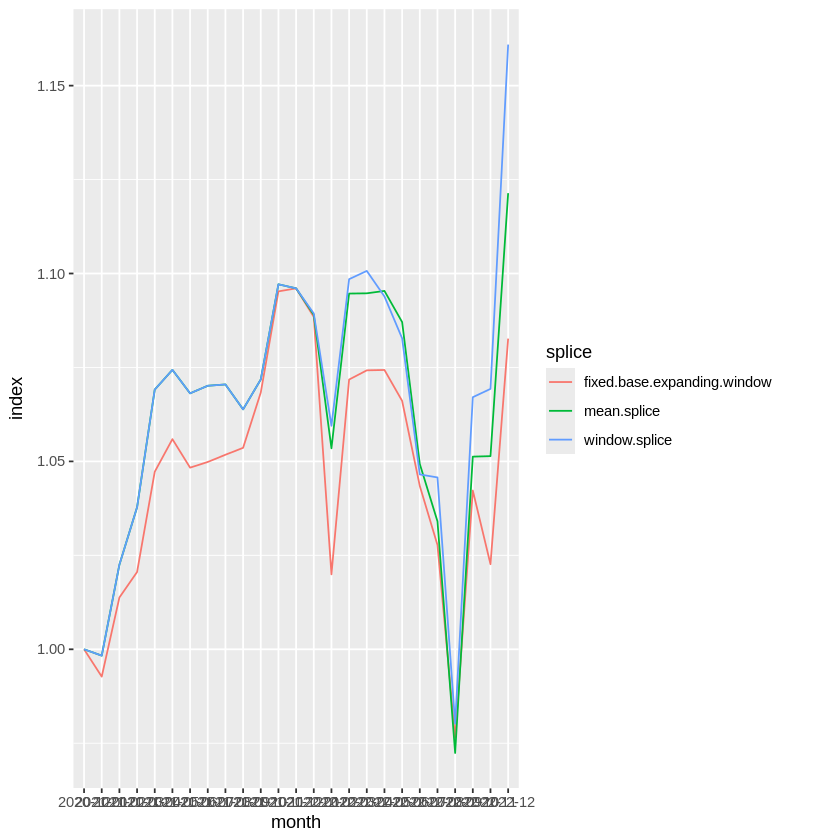

In [ ]:
# Calculation of mean splice
geks_mean <- price_indices(data,
              start="2020-12",
              end="2022-12",
              formula="ccdi_splice", # the name of the formula changed
              window=13,
              interval=TRUE,
              splice = "mean" # "movement", "window","half","mean", "window_published", "half_published" and "mean_published" are the options
)

# Calculation of fbew (must start in december)
geks_fbew <- price_indices(data,
              start="2020-12",
              end="2022-12",
              formula="ccdi_fbew", # window length is always up to 13 months
              interval=TRUE
)


cat("The function GEKSIndex warns us if not all bilateral indices have matched items:/n")
# Calculation of half splice on published index
geks_hasp <- GEKSIndex(data %>% filter(pervar <= 25),
            pvar = "price",
            qvar = "quantity",
            pervar = "pervar",
            prodID = "product_id",
            indexMethod = "tornqvist",
            sample = "matched",
            window = 13,
            splice = "hasp", # "window", "movement", "half", "mean", "fbew", "fbmw", "wisp", "hasp" or mean_pub" are the options
            imputePrices = NULL
)

# The results in one data.frame
splices <- data.frame(month = geks_mean$time,
           "window splice" = geks_hasp,
           "fixed base expanding window" = geks_fbew$ccdi_fbew,
           "mean splice" = geks_mean$ccdi_splice)

# Visualising the results
cat("\n\nVisualisations help to compare the results:")
pivot_longer(splices, cols = -1, names_to = "splice", values_to = "index") %>%
  ggplot(., aes(x = month, y = index, group = splice, color = splice)) + geom_line()
